In [2]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn untuk Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import joblib
import warnings
warnings.filterwarnings('ignore') # Mengabaikan pesan warning agar output bersih

In [3]:
# Membaca dataset
df = pd.read_csv("Sales - Marketing customer dataset.csv")

In [4]:
# Menampilkan 5 data pertama
print("=== 5 Data Pertama ===")
display(df.head())

# Menampilkan informasi dataset
print("\n=== Informasi Dataset ===")
df.info()

# Menampilkan statistik deskriptif
print("\n=== Statistik Deskriptif ===")
display(df.describe())

=== 5 Data Pertama ===


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0



=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  page

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


B. EXPLORATORY DATA ANALYSIS (EDA)

=== Analisis Missing Value ===


,Jumlah Missing,Persentase (%)
coupon_code,6133,40.886667
age,1200,8.000000
total_spent,1050,7.000000
gender,738,4.920000
satisfaction_score,702,4.680000


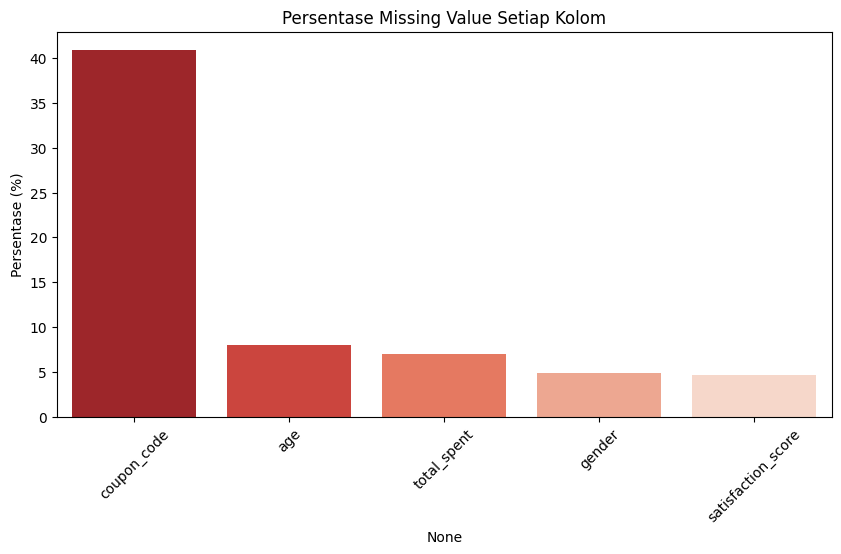


=== Analisis Target (Churn) ===
Jumlah masing-masing kelas:
 churn
0    12702
1     2298
Name: count, dtype: int64

Persentase:
 churn
0    84.68
1    15.32
Name: proportion, dtype: float64


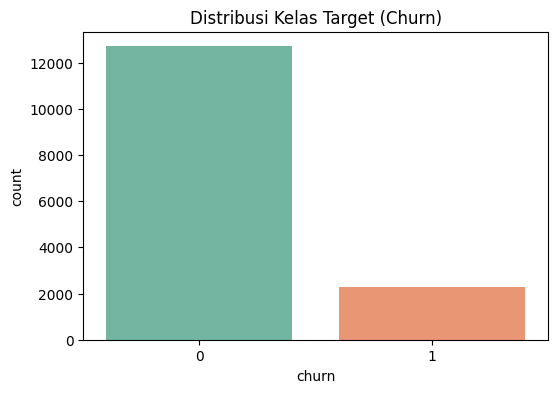

In [5]:
# 1. Analisis Missing Value
print("=== Analisis Missing Value ===")
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_data = pd.DataFrame({'Jumlah Missing': missing_counts, 'Persentase (%)': missing_percent})

# Tampilkan yang hanya memiliki missing value
missing_data = missing_data[missing_data['Jumlah Missing'] > 0].sort_values(by='Persentase (%)', ascending=False)
display(missing_data)

# Visualisasi Bar Chart Missing Value
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_data.index, y=missing_data['Persentase (%)'], palette='Reds_r')
plt.xticks(rotation=45)
plt.title('Persentase Missing Value Setiap Kolom')
plt.ylabel('Persentase (%)')
plt.show()

# 2. Analisis Target (Churn)
print("\n=== Analisis Target (Churn) ===")
print("Jumlah masing-masing kelas:\n", df['churn'].value_counts())
print("\nPersentase:\n", df['churn'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn', palette='Set2')
plt.title('Distribusi Kelas Target (Churn)')
plt.show()

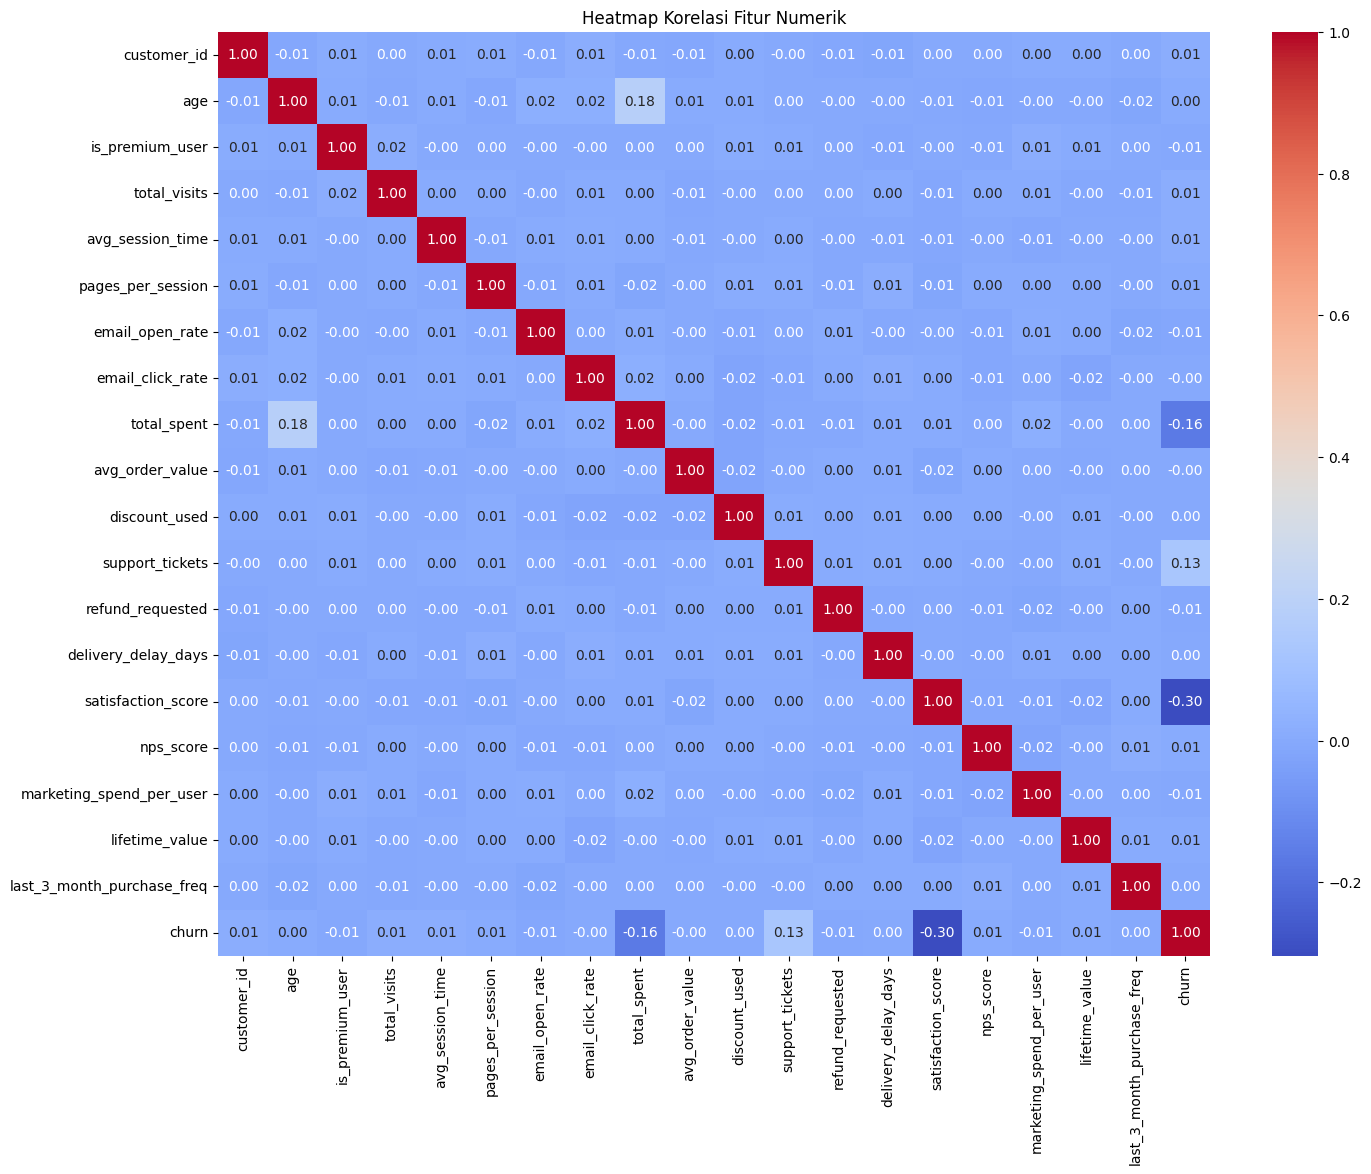

In [6]:
# 3. Analisis Data Numerik (Heatmap Korelasi)
plt.figure(figsize=(16, 12))
# Kita hanya mengambil kolom berjenis numerik untuk melihat korelasi
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

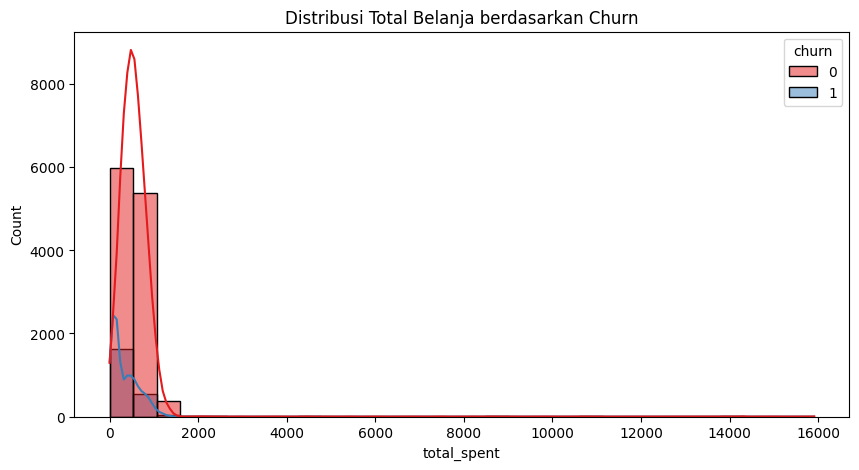

In [7]:
# 4. Analisis Distribusi Data
# Contoh: Melihat distribusi Total Belanja (total_spent) berdasarkan Churn
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='total_spent', hue='churn', kde=True, bins=30, palette='Set1')
plt.title('Distribusi Total Belanja berdasarkan Churn')
plt.show()

C. DIRECT MODELING

=== DIRECT MODELING (Tanpa Preprocessing) ===

Confusion Matrix - Direct Logistic Regression:


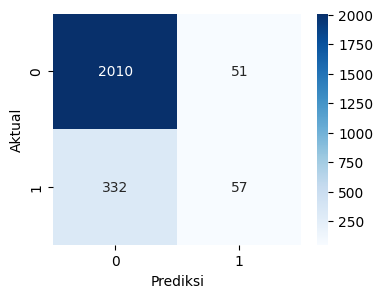


Confusion Matrix - Direct Random Forest:


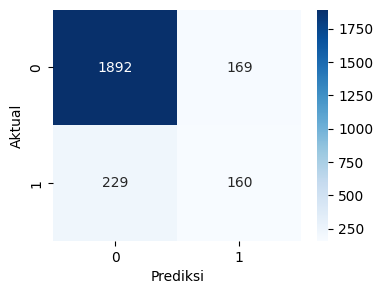


Confusion Matrix - Direct Voting:


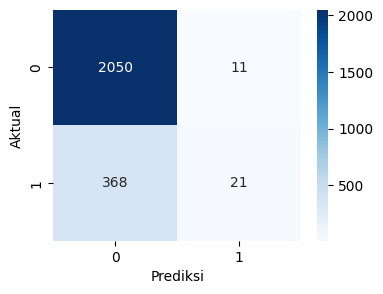

,Model,Accuracy,Precision,Recall,F1 Score
0,Direct Logistic Regression,0.843673,0.527778,0.146530,0.229376
1,Direct Random Forest,0.837551,0.486322,0.411311,0.445682
2,Direct Voting,0.845306,0.656250,0.053985,0.099762


In [8]:
print("=== DIRECT MODELING (Tanpa Preprocessing) ===")

# Menyiapkan data: Hanya mengambil kolom numerik dan membuang missing value
df_direct = df.select_dtypes(include=[np.number]).dropna()

# Menghapus ID karena tidak prediktif
X_direct = df_direct.drop(columns=['churn', 'customer_id'])
y_direct = df_direct['churn']

# 1. Train Test Split (80/20)
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct
)

# 2. Inisialisasi Model
logreg_dir = LogisticRegression(max_iter=1000, random_state=42)
rf_dir = RandomForestClassifier(random_state=42)
knn_dir = KNeighborsClassifier()
svm_dir = SVC(probability=True, random_state=42)

# Voting Classifier
voting_dir = VotingClassifier(
    estimators=[('lr', logreg_dir), ('knn', knn_dir), ('svm', svm_dir)],
    voting='soft'
)

models_direct = {
    'Direct Logistic Regression': logreg_dir,
    'Direct Random Forest': rf_dir,
    'Direct Voting': voting_dir
}

# 3. Latih & Evaluasi
results_direct = []

for name, model in models_direct.items():
    model.fit(X_train_dir, y_train_dir)
    y_pred = model.predict(X_test_dir)

    # Metrik
    acc = accuracy_score(y_test_dir, y_pred)
    prec = precision_score(y_test_dir, y_pred, zero_division=0)
    rec = recall_score(y_test_dir, y_pred, zero_division=0)
    f1 = f1_score(y_test_dir, y_pred, zero_division=0)

    results_direct.append([name, acc, prec, rec, f1])

    # Confusion Matrix
    print(f"\nConfusion Matrix - {name}:")
    cm = confusion_matrix(y_test_dir, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()

# Menampilkan Tabel Evaluasi
df_results_direct = pd.DataFrame(results_direct, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
display(df_results_direct)

D. MODELING DENGAN PREPROCESSING

=== MODELING DENGAN PREPROCESSING ===
Jumlah data duplikat: 0

Confusion Matrix - Preprocessing Logistic Regression:


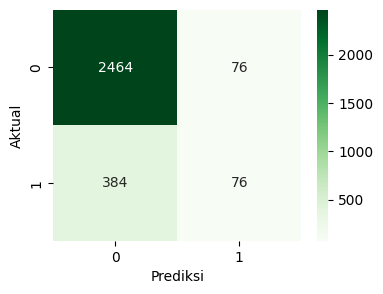


Confusion Matrix - Preprocessing Random Forest:


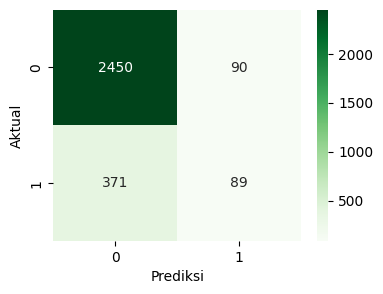


Confusion Matrix - Preprocessing Voting:


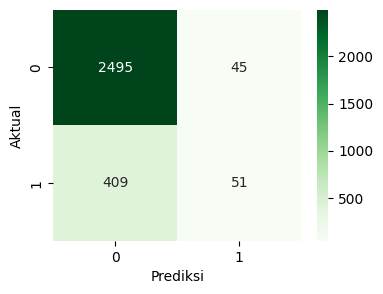

,Model,Accuracy,Precision,Recall,F1 Score
0,Preprocessing Logistic Regression,0.846667,0.500000,0.165217,0.248366
1,Preprocessing Random Forest,0.846333,0.497207,0.193478,0.278560
2,Preprocessing Voting,0.848667,0.531250,0.110870,0.183453


In [9]:
print("=== MODELING DENGAN PREPROCESSING ===")

# 1. Cek Duplikasi
print("Jumlah data duplikat:", df.duplicated().sum())
df_clean = df.drop_duplicates()

# Menghapus kolom identitas / tanggal yang terlalu spesifik untuk dimodelkan langsung
cols_to_drop = ['churn', 'customer_id', 'signup_date', 'last_purchase_date']
X = df_clean.drop(columns=cols_to_drop)
y = df_clean['churn']

# 2. Pisahkan data Train Test (80% / 20%) terlebih dahulu untuk menghindari Data Leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pisahkan nama kolom numerik dan kategorik
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# 3 & 4. Pipeline Scikit-Learn: Imputasi + Scaling + Encoding
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Mengisi outlier/missing dengan median
    ('scaler', StandardScaler())                   # Scaling numerik
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Isi missing text dengan modus
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # One-Hot Encoding
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Membangun ulang 3 Model dengan Pipeline
pipe_lr = Pipeline([('prep', preprocessor), ('model', LogisticRegression(max_iter=1000, random_state=42))])
pipe_rf = Pipeline([('prep', preprocessor), ('model', RandomForestClassifier(random_state=42))])
pipe_voting = Pipeline([('prep', preprocessor), ('model', VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('svm', SVC(probability=True, random_state=42))
    ], voting='soft'
))])

models_prep = {
    'Preprocessing Logistic Regression': pipe_lr,
    'Preprocessing Random Forest': pipe_rf,
    'Preprocessing Voting': pipe_voting
}

results_prep = []

for name, model in models_prep.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrik
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results_prep.append([name, acc, prec, rec, f1])

    # Confusion Matrix
    print(f"\nConfusion Matrix - {name}:")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()

# Menampilkan Tabel Hasil Preprocessing
df_results_prep = pd.DataFrame(results_prep, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
display(df_results_prep)

E. FEATURE IMPORTANCE

=== FEATURE IMPORTANCE ===


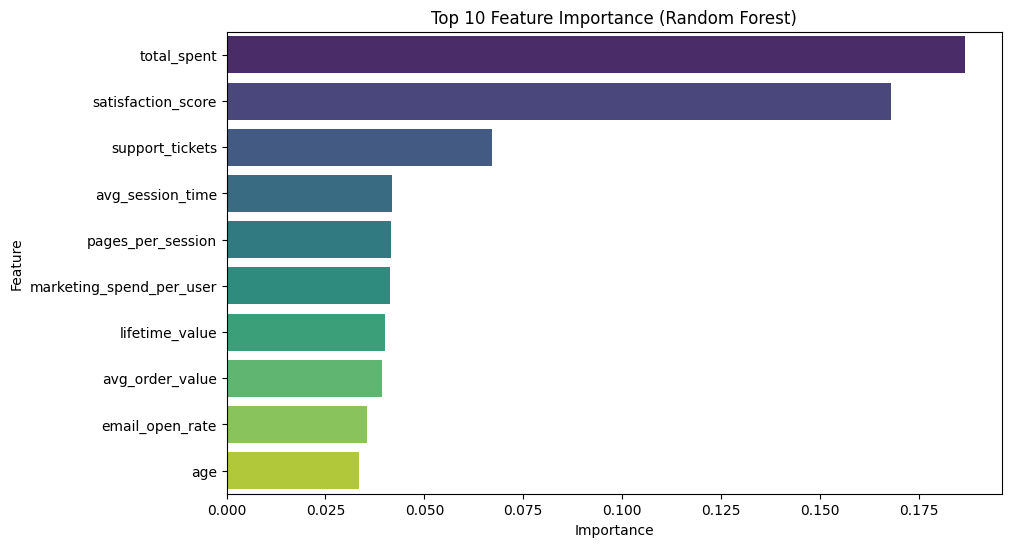

In [10]:
print("=== FEATURE IMPORTANCE ===")

# Mengekstrak model RF terbaik dari Pipeline
best_rf = pipe_rf.named_steps['model']

# Mengambil nama fitur setelah di-Encode
encoded_cat_cols = pipe_rf.named_steps['prep'].transformers_[1][1].named_steps['encoder'].get_feature_names_out(cat_cols)
all_features = np.concatenate([num_cols, encoded_cat_cols])

# Ekstrak tingkat kepentingan fitur
importances = best_rf.feature_importances_
fi_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10) # Ambil 10 Teratas

# Visualisasi Ranking
plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.show()

F. HYPERPARAMETER TUNING

=== HYPERPARAMETER TUNING ===
Best Parameters:
LR: {'model__C': 10, 'model__solver': 'liblinear'}
RF: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Voting: {'model__weights': [1, 1, 2]}

Confusion Matrix - Tuning Logistic Regression:


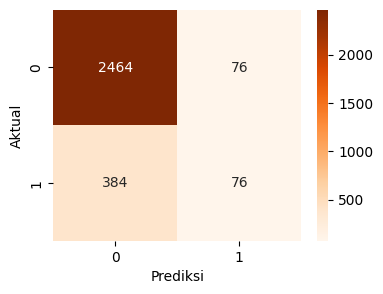


Confusion Matrix - Tuning Random Forest:


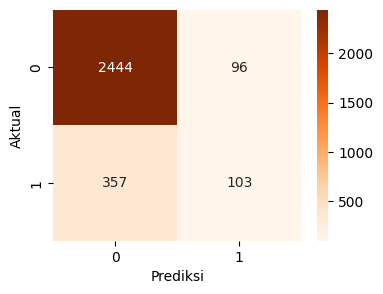


Confusion Matrix - Tuning Voting:


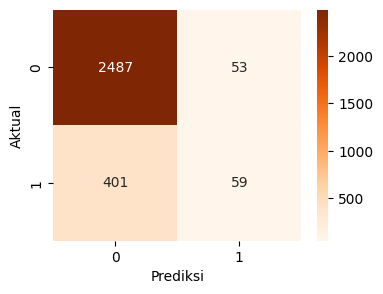

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuning Logistic Regression,0.846667,0.500000,0.165217,0.248366
1,Tuning Random Forest,0.849000,0.517588,0.223913,0.312595
2,Tuning Voting,0.848667,0.526786,0.128261,0.206294


In [11]:
print("=== HYPERPARAMETER TUNING ===")

# 1. Tuning Logistic Regression
param_grid_lr = {
    'model__C': [0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear']
}
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=3, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

# 2. Tuning Random Forest
param_grid_rf = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

# 3. Tuning Voting
param_grid_voting = {
    # Bobot [LR, KNN, SVM]
    'model__weights': [[1, 1, 1], [2, 1, 1], [1, 1, 2]]
}
grid_voting = GridSearchCV(pipe_voting, param_grid_voting, cv=3, scoring='f1', n_jobs=-1)
grid_voting.fit(X_train, y_train)

print("Best Parameters:")
print("LR:", grid_lr.best_params_)
print("RF:", grid_rf.best_params_)
print("Voting:", grid_voting.best_params_)

# Evaluasi Model Tuning
models_tuned = {
    'Tuning Logistic Regression': grid_lr.best_estimator_,
    'Tuning Random Forest': grid_rf.best_estimator_,
    'Tuning Voting': grid_voting.best_estimator_
}

results_tuned = []

for name, model in models_tuned.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results_tuned.append([name, acc, prec, rec, f1])

    print(f"\nConfusion Matrix - {name}:")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()

df_results_tuned = pd.DataFrame(results_tuned, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
display(df_results_tuned)

G. PEMILIHAN MODEL TERBAIK

In [12]:
print("=== PEMILIHAN MODEL TERBAIK ===")

# Gabungkan 9 Model
all_results = pd.concat([df_results_direct, df_results_prep, df_results_tuned], ignore_index=True)

# Urutkan berdasarkan F1 Score tertinggi ke terendah
all_results = all_results.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

display(all_results)

# Mengambil model urutan 1
best_model_name = all_results.iloc[0]['Model']
print(f"\n>>> MODEL TERBAIK BERDASARKAN F1 SCORE ADALAH: {best_model_name} <<<")

=== PEMILIHAN MODEL TERBAIK ===


,Model,Accuracy,Precision,Recall,F1 Score
0,Direct Random Forest,0.837551,0.486322,0.411311,0.445682
1,Tuning Random Forest,0.849000,0.517588,0.223913,0.312595
2,Preprocessing Random Forest,0.846333,0.497207,0.193478,0.278560
3,Tuning Logistic Regression,0.846667,0.500000,0.165217,0.248366
4,Preprocessing Logistic Regression,0.846667,0.500000,0.165217,0.248366
5,Direct Logistic Regression,0.843673,0.527778,0.146530,0.229376
6,Tuning Voting,0.848667,0.526786,0.128261,0.206294
7,Preprocessing Voting,0.848667,0.531250,0.110870,0.183453
8,Direct Voting,0.845306,0.656250,0.053985,0.099762



>>> MODEL TERBAIK BERDASARKAN F1 SCORE ADALAH: Direct Random Forest <<<


H. DEPLOYMENT STREAMLIT

In [14]:
# Berdasarkan hasil tabel, kita ambil estimator terbaik dari pipeline bersangkutan
# Sebagai contoh bila 'Tuning Random Forest' adalah yang menang:
final_best_model = grid_rf.best_estimator_

joblib.dump(final_best_model, 'model.pkl')
print("Model berhasil disimpan sebagai 'model.pkl'")

Model berhasil disimpan sebagai 'model.pkl'


In [15]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd

# Load model
model = joblib.load('model.pkl')

st.title("Prediksi Customer Churn")
st.write("Aplikasi ini memprediksi apakah seorang pelanggan akan Churn atau Tidak.")

# Membuat form input sederhana (Sesuaikan isiannya jika ada kolom spesifik)
age = st.number_input('Umur Pelanggan', min_value=10, max_value=100, value=30)
total_spent = st.number_input('Total Belanja', min_value=0.0, value=500.0)
support_tickets = st.number_input('Jumlah Tiket Bantuan', min_value=0, max_value=20, value=1)
# Untuk demo, kita harus men-supply dataframe sesuai input fitur (Pipeline otomatis mengisi/imputasi sisanya)

if st.button("Prediksi"):
    # Karena kita membuat pipeline utuh, kita butuh DataFrame dummy yang merepresentasikan satu baris penuh
    # (Pastikan di real application semua input dikumpulkan)
    # Ini merupakan implementasi tiruan untuk contoh
    input_data = pd.DataFrame([{
        'age': age,
        'total_spent': total_spent,
        'support_tickets': support_tickets,
        'gender': 'Female', # Sisanya diset dummy/default
        'country': 'UK',
        'is_premium_user': 1
        # Dan fitur-fitur lain yang diminta oleh pipeline
    }])

    try:
        prediction = model.predict(input_data)
        if prediction[0] == 1:
            st.error("Hasil: Customer berpotensi churn!")
        else:
            st.success("Hasil: Customer tidak churn.")
    except Exception as e:
        st.write("Terdapat kesalahan input kolom yang belum terpenuhi untuk pipeline. Error: ", e)

Writing app.py


In [16]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
numpy

Writing requirements.txt
